In [1]:
%load_ext autoreload 
%autoreload 2
import os 
opj = os.path.join
import numpy as np
import glob
import os
import re
import shutil
import subprocess
from pathlib import Path

import nibabel as nib
import numpy as np
import pandas as pd
from nipype.algorithms.confounds import FramewiseDisplacement, ComputeDVARS

from scipy.signal import savgol_filter
from scipy import stats
from sklearn.decomposition import PCA

from cvl_utils.preproc_func import (
    build_output_name,
    check_skip,
    get_labels,
    make_safe_workdir,
    _bold_base,
    _container_path,
    _stage,
    run_cmd,
    _get_tr,
)
from cvl_utils.denoise import (
    PCA_denoiser, 
    SGFilter,
)

#ffa1b2 


In [9]:
subject = 'sub-hp01'
session = 'ses-01'
bids_dir = '/Users/marcusdaghlian/projects/dp-clean-link/240522NG/hypot'
fprep_dir = opj(bids_dir, 'fmriprep')
moco_file = 's2_coreg'
output_file = 's4_conf_PB_style'
task = 'task-pRFLE'
# sg_window = 347
# sg_order = 

In [7]:
subject_fmriprep_dir = opj(bids_dir, 'derivatives', 'fmriprep', subject, session)
subject_input_dir = opj(bids_dir, 'derivatives', moco_file, subject, session)
subject_output_dir = opj(bids_dir, 'derivatives', output_file, subject, session)
if not os.path.exists(subject_output_dir):
    os.makedirs(subject_output_dir)


In [14]:
bold_pattern = os.path.join(
    subject_input_dir, '{}_{}_{}*bold*.nii*'.format(subject, session, task))
bold_files = sorted(glob.glob(bold_pattern))

if not bold_files:
    raise FileNotFoundError(
        'No BOLD files found for {}_{}.  Searched: {}'.format(
            subject, session, bold_pattern)
    )

print('\nFound {} BOLD run(s).'.format(len(bold_files)))
for b in bold_files:
    print('  - {}'.format(os.path.basename(b)))

# per run get the relevant info
rinfo = {
    'bold_file': [],
    'surf_LH' : [], 
    'surf_RH' : [], 
    'brainmask' : [], 
    'fmriprep_confounds_tsv':[], 
    'mcf_par_file' : [],
    'conf' : [],
}
for bold_file in bold_files:
    run_label, task_label = get_labels(bold_file)
    parts = [subject, session]
    if task_label:
        parts.append(task_label)
    if run_label:
        parts.append(run_label)

    # fMRIprep confounds + brainmask — only needed in full denoising mode
    fmriprep_confounds_tsv = None
    brainmask = None
    mcf_par_file = None


    # ------------------------------------------------------------------
    # Locate matching MCFLIRT .par file
    # ------------------------------------------------------------------
    fallback_pat = os.path.join(
        subject_input_dir,
        '{}_*mcflirt*.par'.format('_'.join(parts)))
    par_files = sorted(glob.glob(fallback_pat))
    if not par_files:
        raise FileNotFoundError(
            'No MCFLIRT .par file found for {}'.format(
                os.path.basename(bold_file)))

    mcf_par_file = par_files[0]
    print('  BOLD  : {}'.format(bold_file))
    print('  PAR   : {}'.format(mcf_par_file))

    # ------------------------------------------------------------------
    # Locate fMRIprep confounds .tsv (Step 1 input)
    # ------------------------------------------------------------------
    fmriprep_conf_pattern = os.path.join(
        subject_fmriprep_dir, 'func',
        '{}*desc-confounds_timeseries.tsv'.format('_'.join(parts)))
    fmriprep_conf_hits = sorted(glob.glob(fmriprep_conf_pattern))

    if not fmriprep_conf_hits:
        raise FileNotFoundError(
            'No fMRIprep confounds .tsv found for {}. Searched: {}'.format(
                os.path.basename(bold_file), fmriprep_conf_pattern))

    fmriprep_confounds_tsv = fmriprep_conf_hits[0]
    print('  FMRIPREP CONF: {}'.format(fmriprep_confounds_tsv))

    # ------------------------------------------------------------------
    # Locate fMRIprep brain mask (Step 2 input for DVARS)
    # ------------------------------------------------------------------
    brainmask_pattern = os.path.join(
        subject_fmriprep_dir, 'func',
        '{}*desc-brain_mask.nii.gz'.format('_'.join(parts))
        )
    brainmask_hits = sorted(glob.glob(brainmask_pattern))

    if not brainmask_hits:
        raise FileNotFoundError(
            'No fMRIprep brain mask found for {}. Searched: {}'.format(
                os.path.basename(bold_file), brainmask_pattern))

    brainmask = brainmask_hits[0]
    print('  BRAINMASK    : {}'.format(brainmask))

    # ------------------------------------------------------------------
    # Locate surface timeseries (optional)
    # ------------------------------------------------------------------
    def _find_surf(hemi_letter):
        # *** TO UPDATE ***
        pat = os.path.join(
            subject_input_dir,
            f'{task_label}_{run_label}*space-fsnative_hemi-{hemi_letter}_bold.func.gii'
        )
        hits = sorted(glob.glob(pat))
        return hits[0] if hits else None

    surf_lh = _find_surf('L')
    surf_rh = _find_surf('R')

    if surf_lh:
        print('  SURF-L: {}'.format(surf_lh))
    else:
        print('  SURF-L: not found — surface denoising will be skipped.')
    if surf_rh:
        print('  SURF-R: {}'.format(surf_rh))
    else:
        print('  SURF-R: not found — surface denoising will be skipped.')
    # 
    output_tsv = opj(
        subject_output_dir,
        f'{subject}_{session}_{task_label}_{run_label}_desc-confounds.tsv'
    )

    from s04_confounds import build_confounds_tsv
    work_dir = opj(subject_output_dir, f'{task_label}_{run_label}')
    os.makedirs(work_dir, exist_ok=True)
    merged_cf = build_confounds_tsv(
        fmriprep_confounds_tsv=fmriprep_confounds_tsv,
        mcf_nii=bold_file,
        mcf_par_file=mcf_par_file,
        brainmask=brainmask,
        output_tsv=output_tsv,
        work_dir=work_dir,
    )
    # save 
    rinfo['bold_file'].append(bold_file)
    rinfo['surf_LH'].append(surf_lh)
    rinfo['surf_RH'].append(surf_rh)
    rinfo['brainmask'].append(brainmask)
    rinfo['fmriprep_confounds_tsv'].append(fmriprep_confounds_tsv)
    rinfo['mcf_par_file'].append(mcf_par_file)
    rinfo['conf'].append(merged_cf)






Found 3 BOLD run(s).
  - sub-hp01_ses-01_task-pRFLE_run-01_sdc_bold_space-fsT1_desc-moco_bbreg_bold.nii.gz
  - sub-hp01_ses-01_task-pRFLE_run-02_sdc_bold_space-fsT1_desc-moco_bbreg_bold.nii.gz
  - sub-hp01_ses-01_task-pRFLE_run-03_sdc_bold_space-fsT1_desc-moco_bbreg_bold.nii.gz
  BOLD  : /Users/marcusdaghlian/projects/dp-clean-link/240522NG/hypot/derivatives/s2_coreg/sub-hp01/ses-01/sub-hp01_ses-01_task-pRFLE_run-01_sdc_bold_space-fsT1_desc-moco_bbreg_bold.nii.gz
  PAR   : /Users/marcusdaghlian/projects/dp-clean-link/240522NG/hypot/derivatives/s2_coreg/sub-hp01/ses-01/sub-hp01_ses-01_task-pRFLE_run-01_sdc_bold_desc-mcflirt_motion.par
  FMRIPREP CONF: /Users/marcusdaghlian/projects/dp-clean-link/240522NG/hypot/derivatives/fmriprep/sub-hp01/ses-01/func/sub-hp01_ses-01_task-pRFLE_run-01_desc-confounds_timeseries.tsv
  BRAINMASK    : /Users/marcusdaghlian/projects/dp-clean-link/240522NG/hypot/derivatives/fmriprep/sub-hp01/ses-01/func/sub-hp01_ses-01_task-pRFLE_run-01_desc-brain_mask.nii.g

# Filter explore

In [15]:
from cvl_utils.denoise import *
bold_file = bold_files[0]
tr = _get_tr(bold_file)
lf_filter120 = SGFilter(
    polyorder=3,
    deriv=0,
    window_length=120,
    tr=tr,
)
lf_filter = SGFilter(
    polyorder=3,
    deriv=0,
    window_length=347,
    tr=tr,
)

gii    = nib.load(surf_lh)
arrays = [da.data for da in gii.darrays]
data   = np.vstack(arrays).T.astype(float)   # (vertices, T)

d120 = lf_filter120.filter_data(data)
d347 = lf_filter.filter_data(data)

  TR: 1.0 s
****************
sg_window 120
****************
sg_window 347


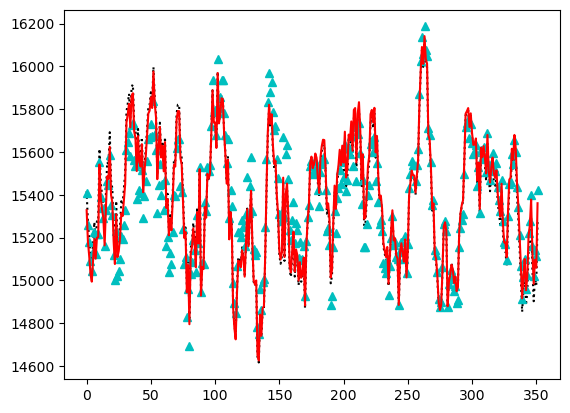

In [16]:
import matplotlib.pyplot as plt
ivx = 0
plt.plot(data[ivx,:], 'k:')
plt.plot(d120[ivx,:], 'c^')
plt.plot(d347[ivx,:], 'r-')


In [ ]:
lf_filter_test = SGFilter(
    polyorder=3,
    deriv=0,
    window_length=50,
    tr=tr,
)

ivx = 0
# plt.plot(data[ivx,:], 'k', lw=2, alpha=0.5)
data_test = lf_filter_test.filter_data(data)
plt.plot(data_test[ivx,:], 'r:', lw=1, alpha=0.8)

# Confounds

In [84]:
# vol testing

func = nib.load(bold_file)
mask = nib.load(brainmask)
from nilearn import masking
data = masking.apply_mask(func, mask).T
data.shape

In [85]:
data.shape

(165312, 352)

In [ ]:
# surf testing
gii    = nib.load(surf_lh)
arrays = [da.data for da in gii.darrays]
data   = np.vstack(arrays).T.astype(float)   # (vertices, T)

In [ ]:

nuissance_vars = [
        # 'csf', 'white_matter',
        # 'a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02', 'a_comp_cor_03', 'a_comp_cor_04',
        # 't_comp_cor_00', 't_comp_cor_01', 't_comp_cor_02', 't_comp_cor_03', 't_comp_cor_04',
        *[f'edge_comp_{i:02}' for i in range(5)],
        # 'std_dvars', 
        # 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z',
        # 'framewise_displacement', 'dvars',
    ]
available = [v for v in nuissance_vars if v in merged_cf.columns]
df_nuis = merged_cf[available]
lf_filter = SGFilter(
    polyorder=3,
    deriv=0,
    window_length=347,
    tr=1.0,
)
pca_denoiser = PCA_denoiser(
    confounds=df_nuis,
    lf_filter=lf_filter,
    ncomps=2,
)
pca_denoiser.run_pca()
data_rm, betas  = pca_denoiser.PCA_regression(
    data
)

# # # data_rm = pca_denoiser.lf_filter.filter_data(data_rm)
# # # # data_rm_niscrub = nilearn.signal.clean(
# # # #     data, detrend=True, confounds=pca_denoiser.pca_comps, standardize='zscore_sample'   
# # # # )
import scipy
data_rm = scipy.stats.zscore(data_rm, axis=-1,)
data_zs = scipy.stats.zscore(data, axis=-1)



****************
sg_window 347


In [90]:
df_nuis

,edge_comp_00,edge_comp_01,edge_comp_02,edge_comp_03,edge_comp_04
0,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...
347,-0.004878,0.063543,-0.061168,-0.007188,0.005817
348,-0.001863,-0.030048,-0.000724,-0.064416,0.006846
349,0.007215,-0.059279,-0.004189,0.065250,0.005732
350,-0.001614,0.063478,-0.071133,0.032870,-0.019190


In [ ]:
# import nilearn
# fd_spike=(merged_cf['framewise_displacement']<1.5).to_numpy()
# data_rm_niscrub = nilearn.signal.clean(
#     data.T, 
#     detrend=True, 
#     confounds=pca_denoiser.pca_comps,
#     standardize='zscore_sample',
#     sample_mask=fd_spike,#interpolate=True,
#     t_r=1.0, 
#     high_pass=0.01,
# ).T

# plt.plot(data_rm_niscrub[ivx,:])

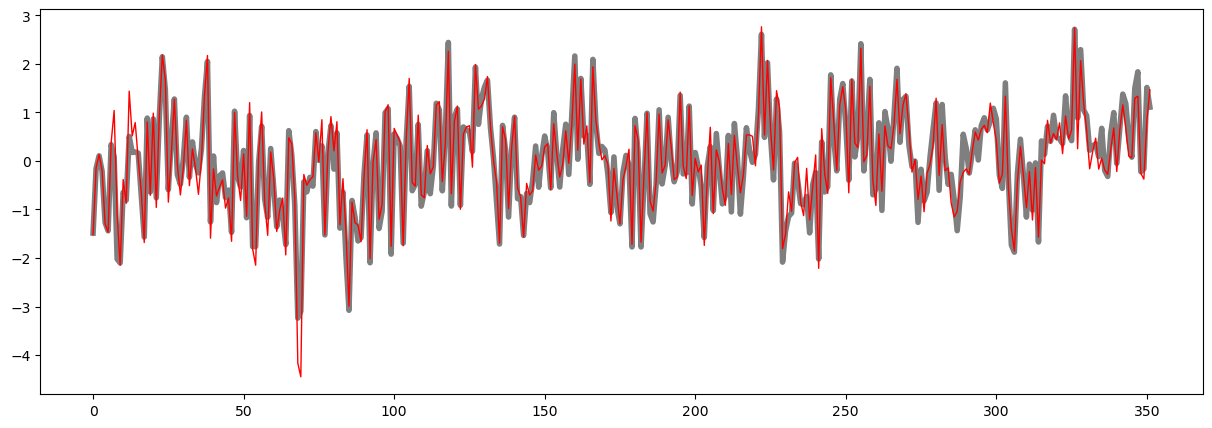

In [91]:
plt.figure(figsize=(15,5))
ivx = 20
plt.plot(data_zs[ivx,:], 'k', lw=4, alpha=0.5)
plt.plot(data_rm[ivx,:], 'r', lw=1, alpha=1)
# plt.plot(data_rm_niscrub[ivx,:], 'b', lw=1)
# plt.plot(merged_cf['framewise_displacement'])

In [40]:
mask_data = mask.get_fdata()

In [179]:
def quick_glm(data, df):
    df = df.fillna(0)
    conf = df.to_numpy().T
    conf = scipy.stats.zscore(conf, axis=-1)
    print(conf.shape)
    ones_ = np.ones(conf.shape[-1])[np.newaxis,...]
    print(ones_.shape)
    dm = np.vstack([ones_, conf]).T
    print(dm.shape)
    print(data.shape)
    # Do OLS
    betas = np.linalg.lstsq(dm, data.T,rcond=-1)[0]
    # Predictions are dot product of dm and betas.
    yhat = np.dot(dm, betas).T

    # Get residuals
    resid=data-yhat

    # Add back in intercept
    resid+= np.nanmean(data,axis=-1)[:,np.newaxis]
    out_df = pd.DataFrame(betas.T, columns=['interc', *df.columns])
    return resid, out_df


tvars = [
        'csf', 
        'white_matter',
        'a_comp_cor_00', 'a_comp_cor_01', 'a_comp_cor_02', 'a_comp_cor_03', 'a_comp_cor_04',
        't_comp_cor_00', 't_comp_cor_01', 't_comp_cor_02', 't_comp_cor_03', 't_comp_cor_04',
        # *[f'edge_comp_{i:02}' for i in range(5)],
        # *[f'cosine{i:02}' for i in range(3)],
        # 'std_dvars', 
        'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z',
        'framewise_displacement', 'dvars',
    ]
tdf = merged_cf[tvars]

dn,out_df = quick_glm(
    data, tdf,
)

(20, 352)
(1, 352)
(352, 21)
(165312, 352)


In [171]:
out_df

,interc,trans_x,trans_y,trans_z,rot_x,rot_y,rot_z,framewise_displacement,dvars
0,2485.013369,89.085730,170.979266,42.119130,159.650575,111.901836,-98.777651,-13.119815,15.151724
1,3319.122936,154.424340,201.766937,60.846037,183.045759,143.802346,-89.872808,-11.698843,17.203475
2,3132.081260,213.594422,85.509535,96.794987,122.584228,141.987319,32.460241,5.012322,1.486794
3,2209.749335,67.113824,-160.075999,62.538633,-53.136164,13.261431,144.398472,20.330489,-0.730224
4,3112.506262,236.164030,244.095746,70.372266,311.618900,231.270306,-52.433822,-5.007949,29.333673
...,...,...,...,...,...,...,...,...,...
165307,5292.756421,-40.176827,-224.337335,-0.964755,-155.610977,-72.644463,128.438157,7.558483,-14.975736
165308,7067.129431,-113.570383,-298.213656,-26.793875,-255.360596,-149.471015,142.740711,13.131670,-26.979258
165309,7437.010968,-111.791845,-218.535079,6.366392,-224.839751,-136.386399,54.891929,14.735640,-32.170738
165310,6528.811358,-29.207821,-27.400426,28.160737,-53.170329,-20.317650,-41.952317,-6.758255,-11.417224


/var/folders/01/hhsk37310zsgzgg1nhgs6rfm0000gn/T/ipykernel_61164/1309022017.py:5: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  plotting.view_img(b1, bg_img=None, threshold=None, cmap='RdBu', vmin=-100, vmax=100)



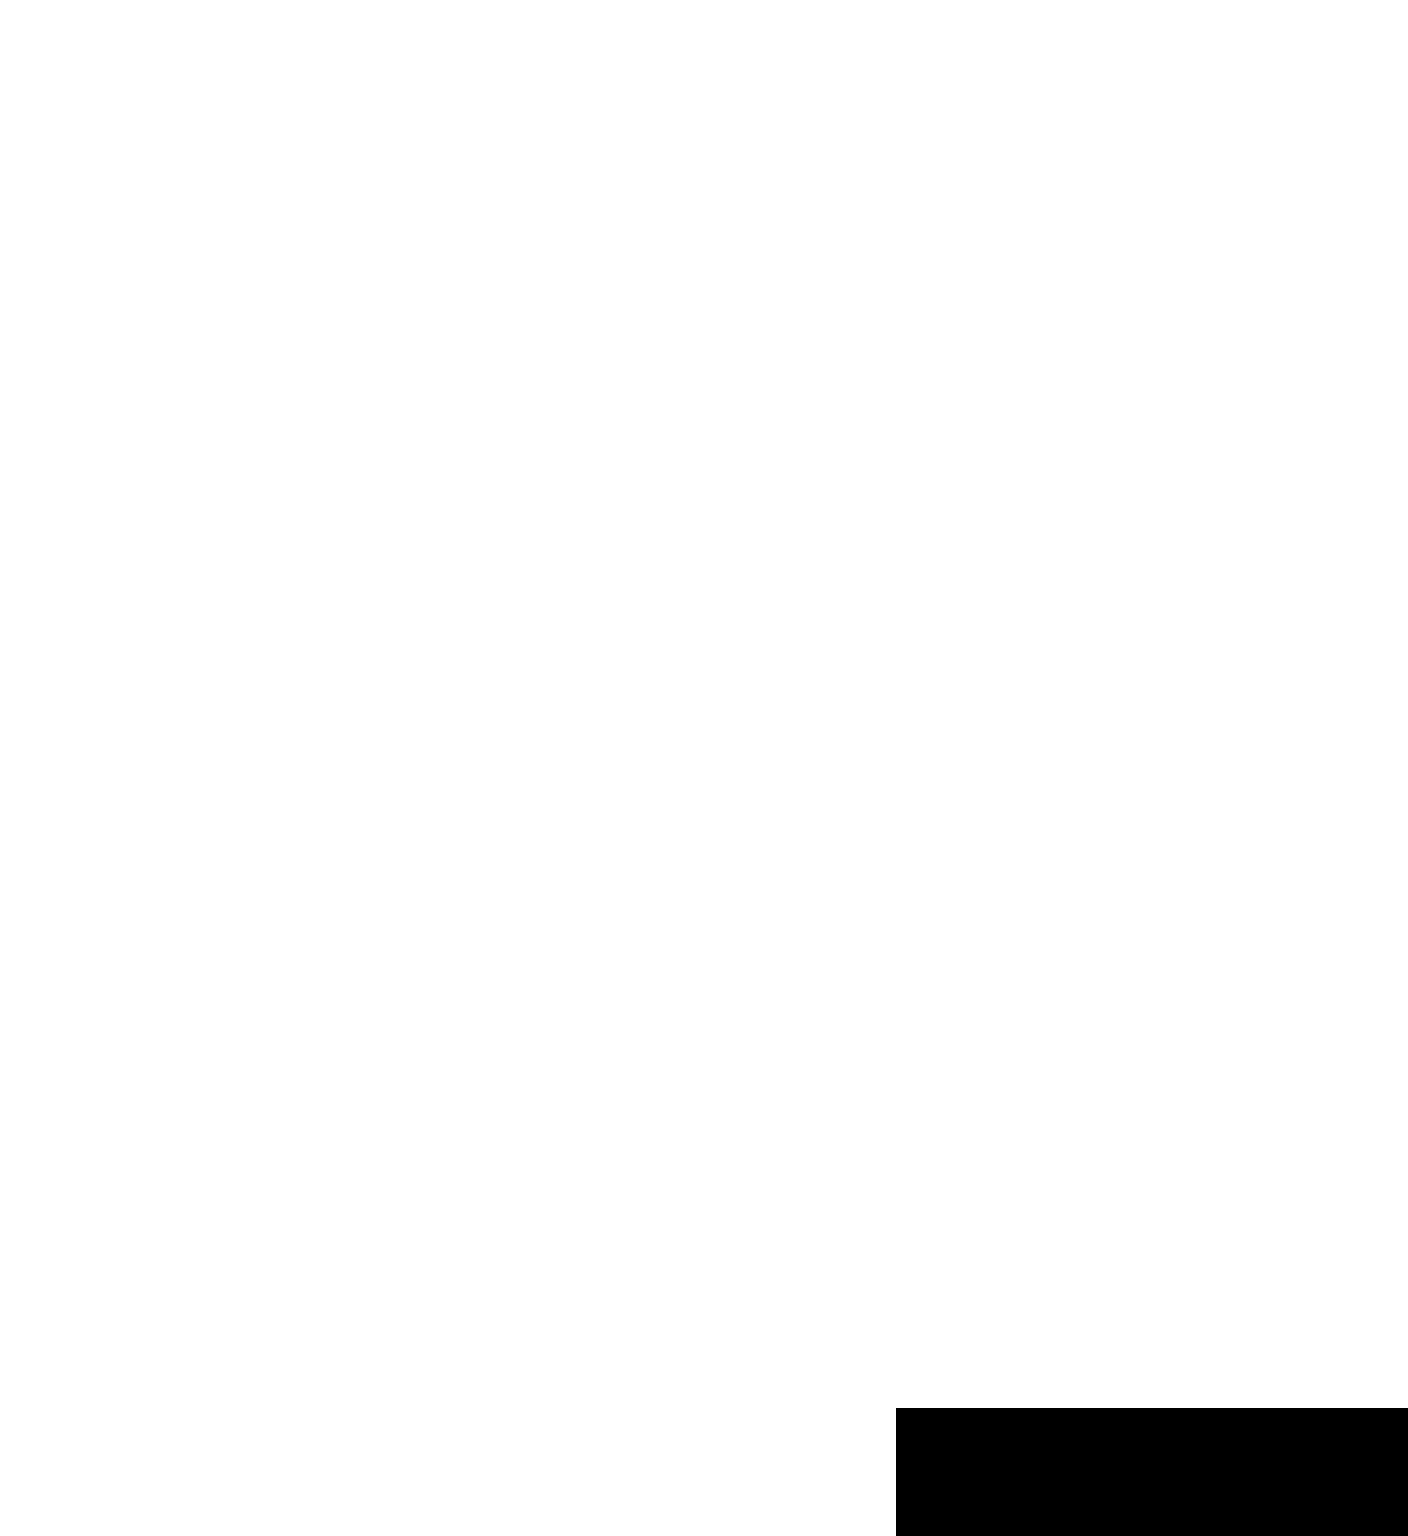
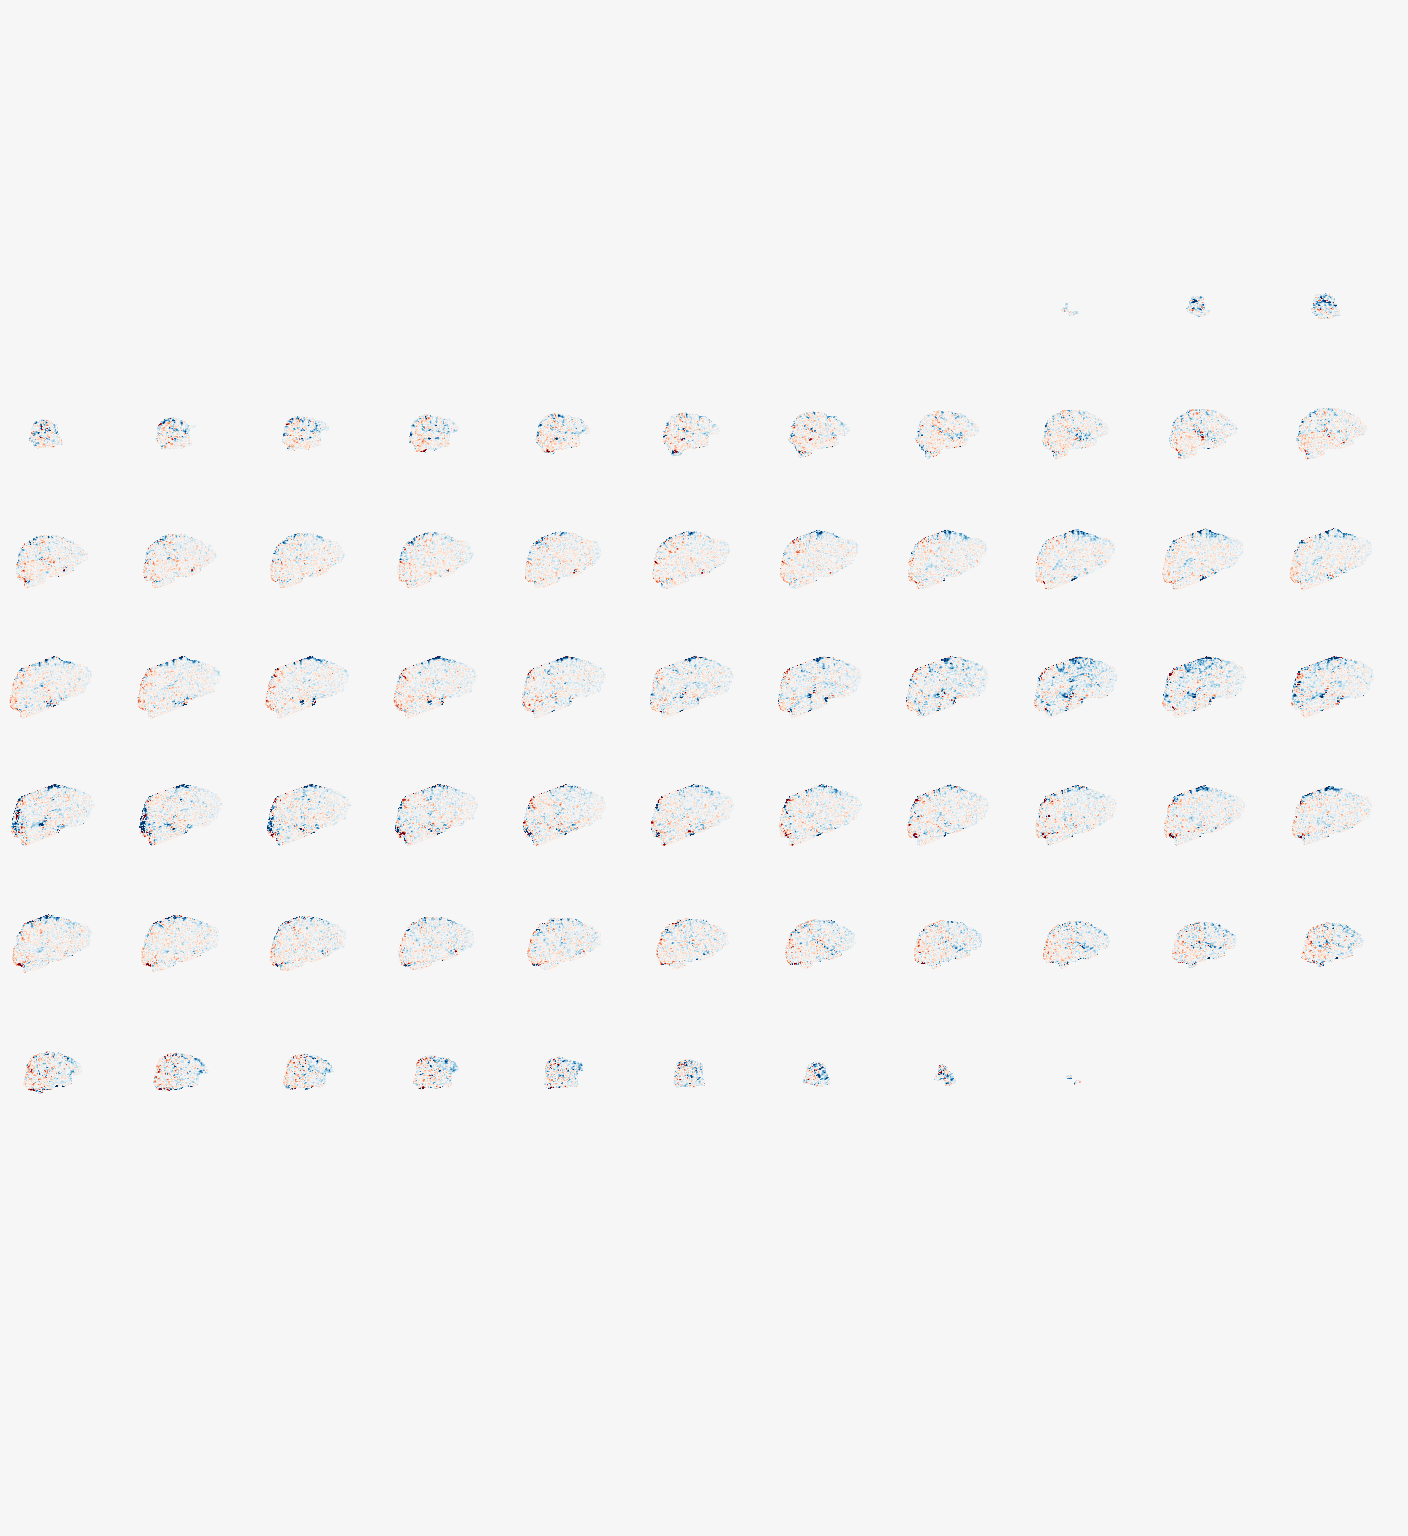

In [181]:
b1 = masking.unmask(out_df['csf'], mask) #.get_fdata()

from nilearn import plotting

plotting.view_img(b1, bg_img=None, threshold=None, cmap='RdBu', vmin=-100, vmax=100)

# def quick_vol(vol,mask):
#     fig,axs = plt.subplots(3,3,figsize=(10,10))
#     axs = axs.flatten()
#     for i,sl in enumerate([25,50,75]):
#         axs[i].imshow((vol*mask)[:,:,sl])
# quick_vol(b1, mask_data)

In [61]:
disp.close()

ModuleNotFoundError: No module named 'ipyniivue'

TypeError: input should be a NiftiLike object or an iterable of NiftiLike object. Got: ndarray

In [44]:
mask_data

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

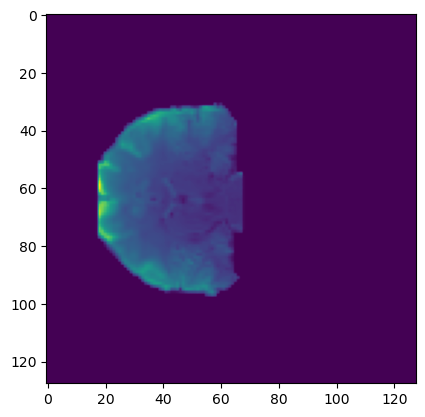

In [ ]:
merged_cf['framewise_displacement']

In [ ]:
from nilearn.signal import clean
data_dn_nilearn = clean(data.T, detrend=True, standardize=None, confounds=pca_denoiser.pca_comps).T

In [ ]:
ivx = 0
plt.figure(figsize=(20,5))
plt.plot(data[ivx,:], 'k', lw=5, alpha=0.5)
plt.plot(data_dn_roni[ivx,:])
# plt.plot(data_dn_nilearn[ivx,:])


# Pybest testing

In [ ]:
# Make pb friendly confs - follow _load_single_confound
from conf_denoise.utils import hp_filter
def _clean_confs_pb(
        df, 
        tr, 
        n_skip, 
        high_pass, 
        high_pass_type,
        slice_time_ref,
        n_components, 
    ):
    df = df.iloc[n_skip:]
    decomposer = PCA() #if decomposition == "pca" else FastICA(max_iter=1000)

    # Drop cosine drift and global signal columns
    drop_cols = [c for c in df.columns if "cosine" in c or "global" in c]
    df = df.drop(columns=drop_cols)
    df = df.fillna(0)

    data = hp_filter(
        df.to_numpy(), tr,
        high_pass=high_pass,
        high_pass_type=high_pass_type,
        slice_time_ref=slice_time_ref,
        standardize=False,
    )
    # Decompose
    data = decomposer.fit_transform(data)
    data = data[:, :n_components]

    # High-pass filter again and z-score for orthogonality
    data = hp_filter(
        data, tr,
        high_pass=high_pass,
        high_pass_type=high_pass_type,
        slice_time_ref=slice_time_ref,
        standardize="zscore",
    )

    cols = [f"comp_{str(i + 1).zfill(3)}" for i in range(data.shape[1])]
    return pd.DataFrame(data, columns=cols)
rpca = []
for tconf in rinfo['conf']:

    rpca.append(_clean_confs_pb(
        df=tconf, 
        tr=1.0, 
        n_skip=0, 
        high_pass=0.01,
        high_pass_type="dct",
        slice_time_ref=0.5,
        n_components=50, 
    ))
rpca = pd.concat(rpca)

/Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/240522NG/hypot/code/hypot_code/conf_denoise/conf_denoise/utils.py:118: FutureWarning: boolean values for 'standardize' will be deprecated in nilearn 0.15.0.
Use 'zscore_sample' instead of 'True' or use 'None' instead of 'False'.
  return signal.clean(data, detrend=False, standardize=standardize, confounds=hp_set)
/Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/240522NG/hypot/code/hypot_code/conf_denoise/conf_denoise/utils.py:118: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  return signal.clean(data, detrend=False, standardize=

In [35]:
# load the data
data = []
run_idx = []
for iR,tgii_file in enumerate(rinfo['surf_LH']):
    
    tgii    = nib.load(tgii_file)
    arrays = [da.data for da in tgii.darrays]
    tdata   = np.vstack(arrays).T.astype(float)   # (vertices, T)
    data.append(tdata)
    run_idx.append(np.ones(tdata.shape[-1])*iR)
run_idx = np.hstack(run_idx)
data = np.hstack(data)


In [36]:

from conf_denoise.denoise import denoise
pb_dir = opj(subject_output_dir, f'pbtest001_{task}')
if not os.path.exists(pb_dir):
    os.makedirs(pb_dir, exist_ok=True)
# For func
denoised_func, opt_n_comps = denoise(
    func_data=data.T,
    conf_data=rpca,
    run_idx=run_idx,
    # n_comps=50,
    # cv_splits=5,
    # cv_repeats=1,
    # regularize_across_runs=False,
    # argmax_percent=5.0,
    n_jobs=4,
    random_state=None,
    save_dir=pb_dir,
    f_base=f'{task_label}_{run_label}',
    mask=None,
    save_all=True,
)

In [42]:
opt_n_comps.max(axis=1)

array([1, 9, 1])

In [48]:
data_zs = scipy.stats.zscore(data,axis=-1)
data_dn = denoised_func.T

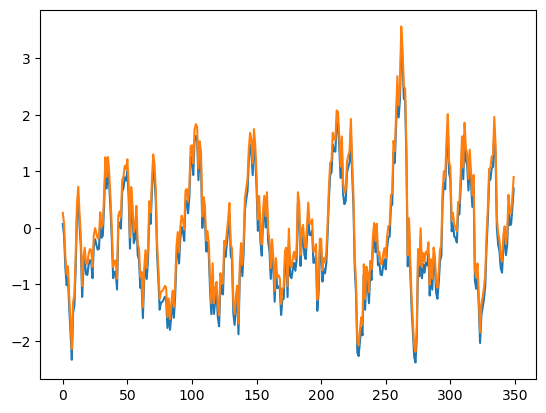

In [51]:
plt.plot(data_zs[ivx,:350])
plt.plot(data_dn[ivx,:350])

In [46]:
denoised_func.shape

(1056, 139230)

#### pb old 

In [ ]:
gii    = nib.load(surf_lh)
arrays = [da.data for da in gii.darrays]
data   = np.vstack(arrays).T.astype(float)   # (vertices, T)
pb_dir = opj(
    subject_output_dir,
    f'pbtest001_{task_label}_{run_label}'
    )
if not os.path.exists(pb_dir):
    os.makedirs(pb_dir, exist_ok=True)
print(merged_cf)

In [ ]:
# Make pb friendly confs - follow _load_single_confound
from conf_denoise.utils import hp_filter
def _clean_confs_pb(
        df, 
        tr, 
        n_skip, 
        high_pass, 
        high_pass_type,
        slice_time_ref,
        n_components, 
    ):
    df = df.iloc[n_skip:]
    decomposer = PCA() #if decomposition == "pca" else FastICA(max_iter=1000)

    # Drop cosine drift and global signal columns
    drop_cols = [c for c in df.columns if "cosine" in c or "global" in c]
    df = df.drop(columns=drop_cols)
    df = df.fillna(0)

    data = hp_filter(
        df.to_numpy(), tr,
        high_pass=high_pass,
        high_pass_type=high_pass_type,
        slice_time_ref=slice_time_ref,
        standardize=False,
    )
    # Decompose
    data = decomposer.fit_transform(data)
    data = data[:, :n_components]

    # High-pass filter again and z-score for orthogonality
    data = hp_filter(
        data, tr,
        high_pass=high_pass,
        high_pass_type=high_pass_type,
        slice_time_ref=slice_time_ref,
        standardize="zscore",
    )

    cols = [f"comp_{str(i + 1).zfill(3)}" for i in range(data.shape[1])]
    return pd.DataFrame(data, columns=cols)
pb_pca = _clean_confs_pb(
    df=merged_cf, 
    tr=1.0, 
    n_skip=0, 
    high_pass=0.01,
    high_pass_type="dct",
    slice_time_ref=0.5,
    n_components=50, 

)

In [ ]:
def _clean_confs_rm(df,tr,n_components):
  drop_cols = [c for c in df.columns if "cosine" in c or "global" in c]
  df = df.drop(columns=drop_cols)
  df = df.fillna(0)
  lf_filter = SGFilter(
    polyorder=3,
    deriv=0,
    window_length=347,
    tr=tr,
  )

  pca_denoiser = PCA_denoiser(
    confounds=df,
    lf_filter=lf_filter,
    ncomps=n_components,
  )
  pca_denoiser.run_pca()
  data = pca_denoiser.pca_comps
  cols = [f"comp_{str(i + 1).zfill(3)}" for i in range(data.shape[1])]
  return pd.DataFrame(data, columns=cols)

      

    
rm_pca = _clean_confs_rm(
  df=merged_cf,
  tr=1.0, 
  n_components=50,
  )

In [ ]:
plt.plot(pb_pca['comp_002'])
plt.plot(rm_pca['comp_002'])

In [ ]:
from conf_denoise.denoise import denoise
# For func
denoised_func, opt_n_comps = denoise(
    func_data=data.T,
    conf_data=pb_pca,
    run_idx=np.ones(data.shape[-1]),
    # n_comps=50,
    # cv_splits=5,
    # cv_repeats=1,
    # regularize_across_runs=False,
    # argmax_percent=5.0,
    n_jobs=1,
    random_state=None,
    save_dir=pb_dir,
    f_base=f'{task_label}_{run_label}',
    mask=None,
    save_all=True,
)

In [ ]:
from conf_denoise.denoise import denoise
# For func
denoised_func, opt_n_comps = denoise(
    func_data=data.T,
    conf_data=pb_pca,
    run_idx=np.ones(data.shape[-1]),
    # n_comps=50,
    # cv_splits=5,
    # cv_repeats=1,
    # regularize_across_runs=False,
    # argmax_percent=5.0,
    n_jobs=1,
    random_state=None,
    save_dir=pb_dir,
    f_base=f'{task_label}_{run_label}',
    mask=None,
    save_all=True,
)

In [ ]:
np.where(opt_n_comps>0)

In [ ]:
import scipy
data_zs = scipy.stats.zscore(data, axis=-1)

In [ ]:
ivx = 1
# plt.plot(data_zs[ivx,:])
# plt.plot(denoised_func.T[ivx,:])
plt.plot(scipy.stats.zscore(data_dn_roni[ivx,:], axis=-1))

In [ ]:
np.isnan(data).sum()

In [ ]:
data.shape

In [ ]:
data.shape